In [1]:
import numpy as np
import functions as fn
from tensorflow import keras as ks
from tqdm import tqdm
import matplotlib.pyplot as plt
model = ks.models.load_model('cii_model_silva.h5')

In [15]:
par=np.loadtxt('data/params_t')
par_og=np.loadtxt('data/params_LH.txt')
dpk=np.loadtxt('data/cii_dpk_silva')
k=np.loadtxt('data/k.txt')
nbins=np.loadtxt('data/nbins.txt')

# 1. Comparison plot

In [16]:
ind=np.random.randint(low=0,high=len(par),size=9)
params_test=par[ind]
dpk_test=dpk[ind]

In [17]:
sv=np.empty((9,6))
for i in range(len(ind)):
    for j in range(len(dpk_test[0])):
        sv[i,j]=dpk_test[i,j]/nbins[j]

In [18]:
dpk_pred=[]
for el in tqdm(params_test):
    par_m = np.reshape(el, (1, 2))
    cii=model.predict(par_m,verbose=0)[0]
    cii=np.exp(15*cii)
    dpk_pred.append(np.array(cii))

100%|██████████| 9/9 [00:00<00:00, 30.85it/s]


In [19]:
params_test=par_og[ind]

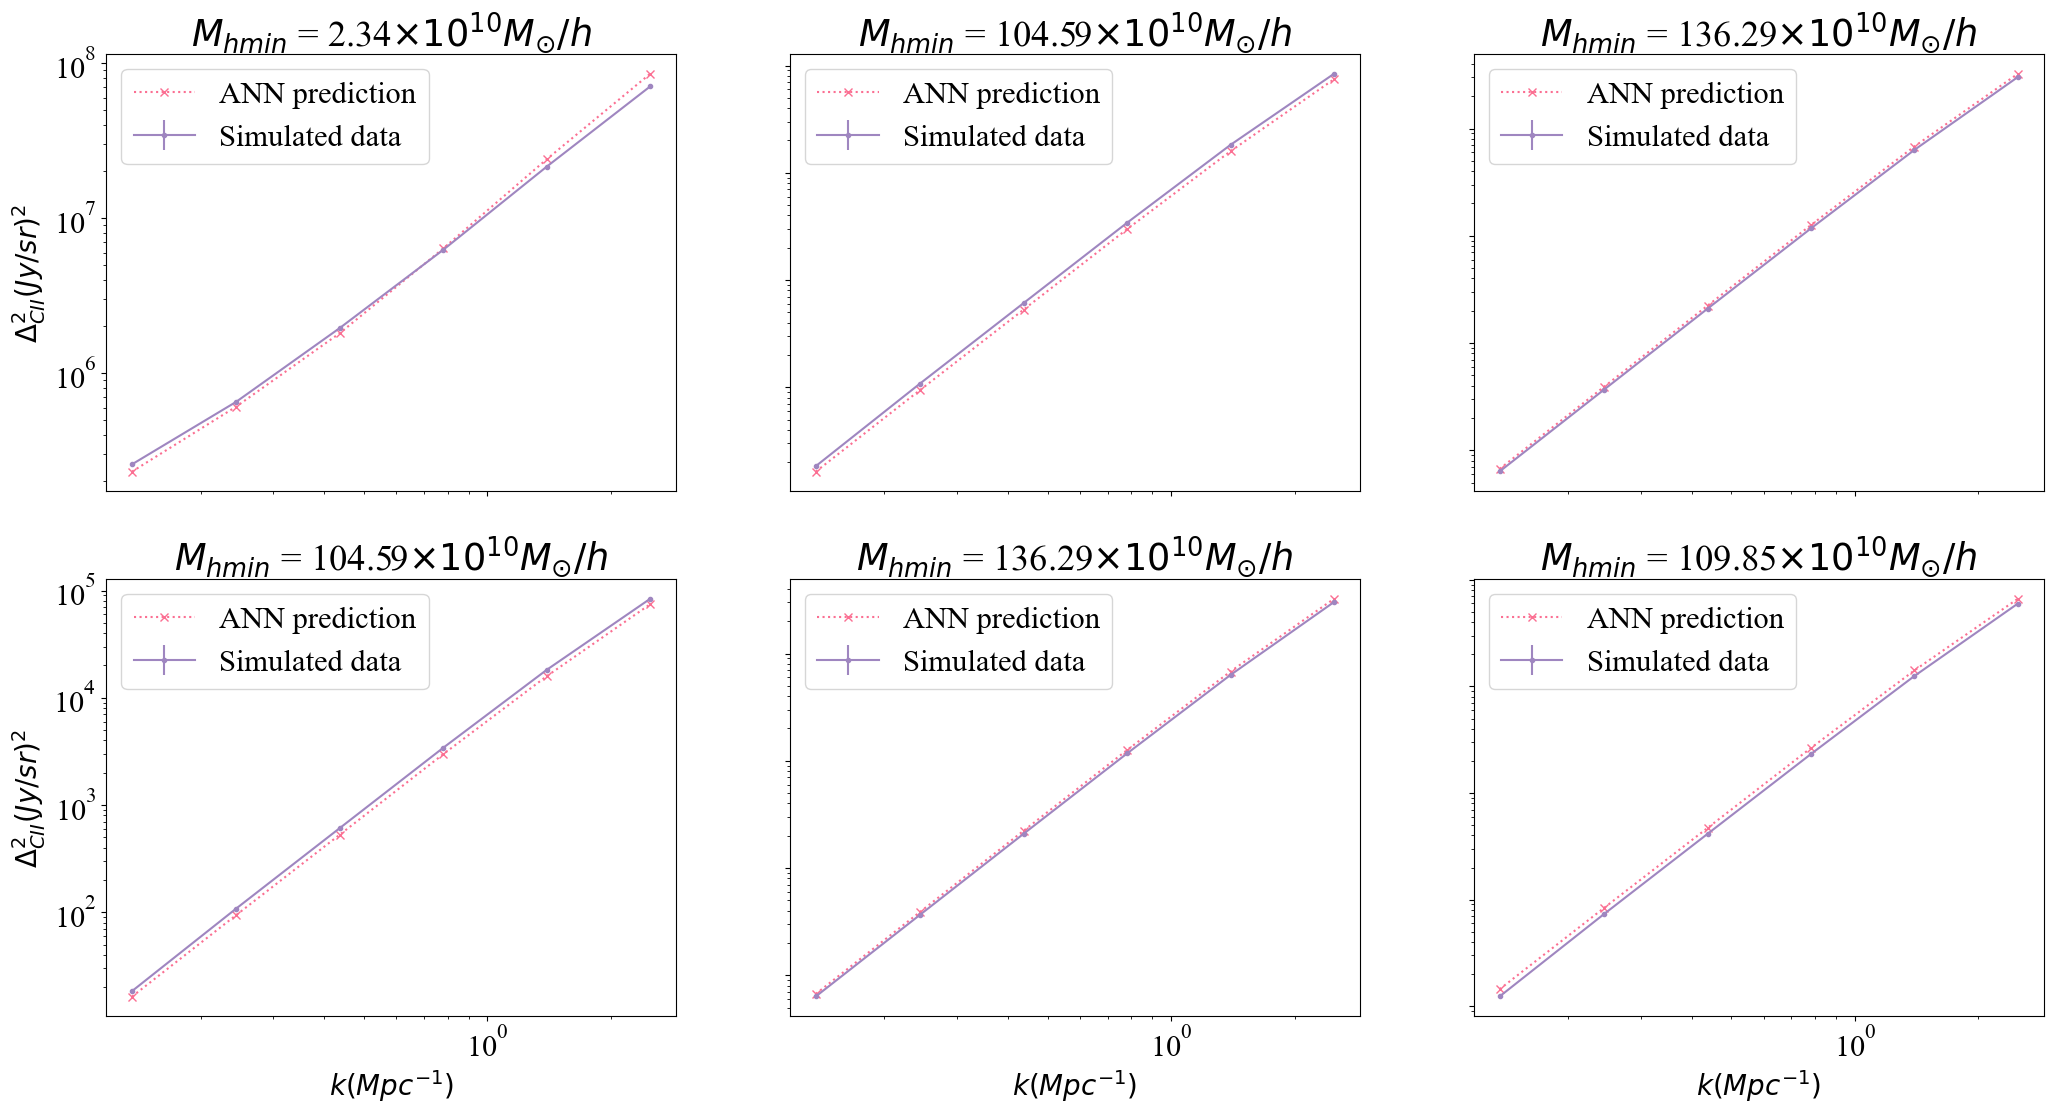

In [25]:
import matplotlib as mpl

# Set the font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']=22
fig,axs=plt.subplots(2,3,figsize=(25,12.5))

for i in range(2):
    for j in range(3):
        axs[i,j].set_title(r'$ M_{hmin} $ = '+"{:.2f}".format(params_test[int(i+j),0])+r'$ \times 10^{10} M_{\odot}/h $')

for ax in axs.flat:
    ax.set_xlabel(r'$k (Mpc^{-1})$',fontsize=20)
    ax.set_ylabel(r'$ \Delta^2_{CII} (Jy/sr)^2$',fontsize=20)

for i in range(2):
    for j in range(3):
        axs[i,j].set_xscale('log')
        axs[i,j].set_yscale('log')
        axs[i,j].plot(k,dpk_pred[int(i+j)],label='ANN prediction',ls='dotted',c='#fb6f92',marker='x')
        axs[i,j].errorbar(k,dpk_test[int(i+j)],label='Simulated data',c='#9f86c0',xerr=None,yerr=sv[int(i+j)],marker='.')

for ax in axs.flat:
    ax.label_outer()
    ax.legend(loc='best')

plt.savefig("figures/comparison_plot.pdf",bbox_inches='tight',dpi=300)

# 2. History plot

In [3]:
history_dict.keys()

dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])

In [10]:
# Load the history
history_array = np.load('cii_history_silva.npy', allow_pickle=True)

# Access the first (and only) item in the array to get the dictionary
history_dict = history_array.item()

# Now you can access the data in the dictionary
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['root_mean_squared_error']
val_accuracy = history_dict['val_root_mean_squared_error']

# Continue with your processing...


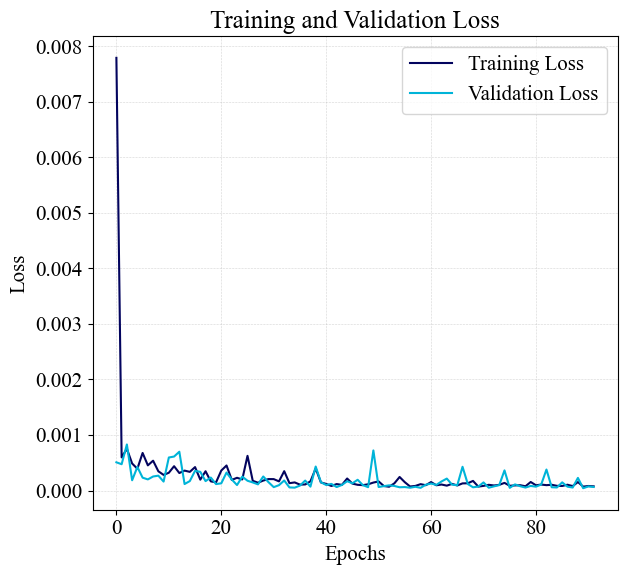

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set the font and font size
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']=15

# Plot training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(loss, label='Training Loss',c='#03045e')
plt.plot(val_loss, label='Validation Loss',c='#00b4d8')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(ls='dotted',lw=0.4)

# Plot training and validation accuracy
# plt.subplot(1, 2, 2)
# plt.plot(accuracy, label='Training Accuracy',c='magenta')
# plt.plot(val_accuracy, label='Validation Accuracy',c='cyan')
# plt.title('Training and Validation Root-Mean Squared error')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()

plt.grid(ls='dotted',lw=0.4)
plt.tight_layout()

plt.savefig("figures/history.pdf",bbox_inches='tight',dpi=300)

# Powerspectrum training set plot

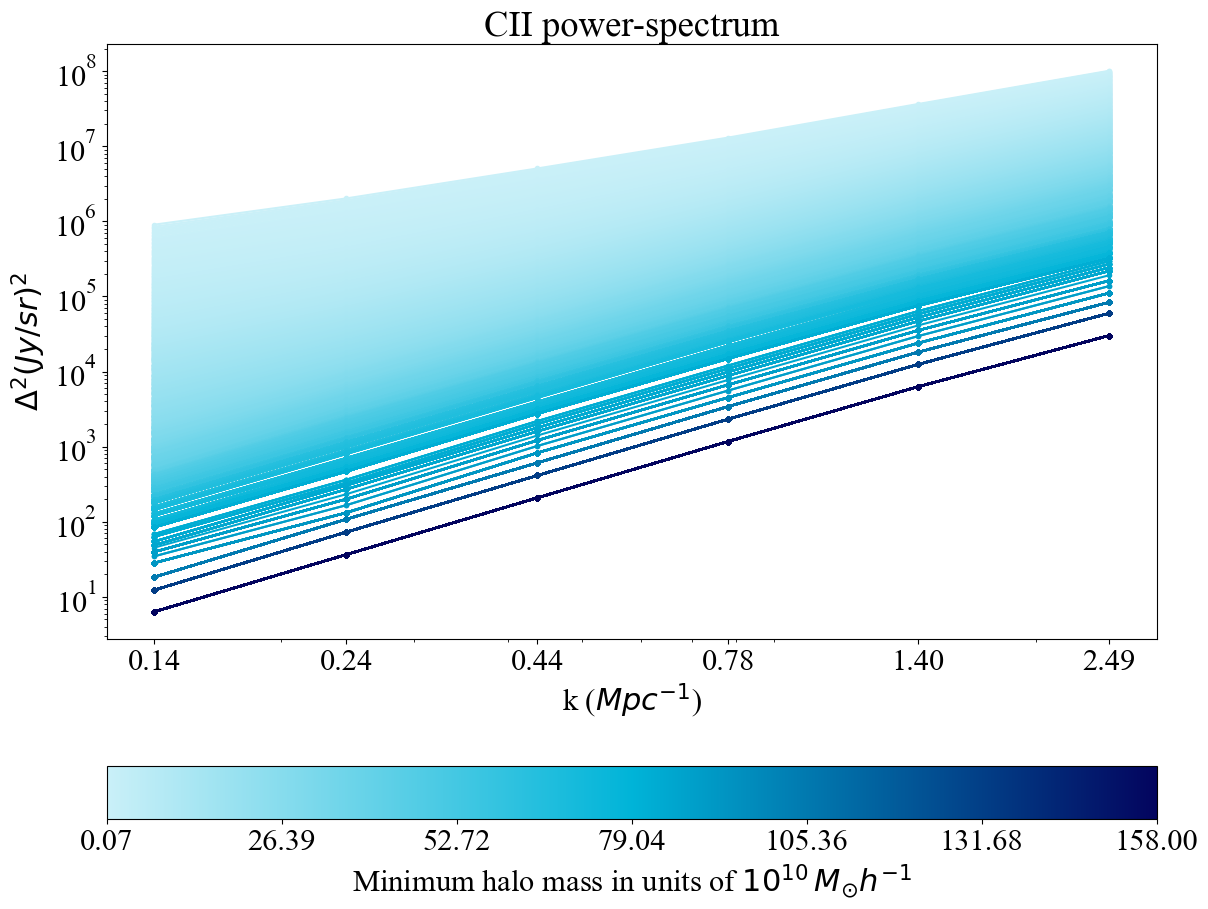

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

colors = ["#caf0f8", "#00b4d8", "#03045e"]
n_bins=len(dpk)
cmap=LinearSegmentedColormap.from_list("CustomColormap", colors, N=n_bins)
norm = Normalize(vmin=0, vmax=10^7)

# Set the font and font size
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']=22

fig = plt.figure(figsize=(15,10))
ax1 = fig.add_axes([0.10,0.10,0.70,0.85])

plt.xscale("log")
plt.yscale("log")

for i in range(len(dpk)):
    ax1.plot(k,dpk[i],c=cmap(i),marker='.')


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

t=np.linspace(0,10^7,7)

l=np.linspace(0.073,158,7)

l=['{:.2f}'.format(el) for el in l]
c=fig.colorbar(sm, ticks=t,ax=ax1,orientation='horizontal')
c.ax.set_xticklabels(l)
kl=['{:.2f}'.format(el) for el in k]
plt.xticks(ticks=k,labels=kl)
plt.xlabel(r'k ($Mpc^{-1}$)')
plt.ylabel(r'$\Delta^2 (Jy/sr)^2$')
plt.title('CII power-spectrum')
c.set_label(r"Minimum halo mass in units of $10^{10} \, M_{\odot} h^{-1}$")

plt.savefig('figures/training_set.pdf',bbox_inches='tight',dpi=300)

# Getting SFR

In [45]:
M0 = 6.6*10**(-5)
Ma = 1.0*10**8
Mb = 1.6*10**11
a = 2.25
b = -2.3

def sfr(M):
    sfr=M0*(M/Ma)**a*(1+(M/Mb))**b
    return sfr

In [32]:
sfr(1.0)

6.599999999905127e-23

In [39]:
import numpy as np

def sfr(M, mu, mn, M0, Ma, Mb, a, b, N=10000):
    # M is the mean value for the M parameter.
    # mu and mn are the positive and negative uncertainties, respectively.
    # This function will generate M values considering the asymmetric uncertainties,
    # calculate SFR for each, and return the median and the +s1, -s2 uncertainties.

    # Generating M values with asymmetric uncertainties
    # Simple approach: split the generation in two to reflect + and - uncertainties
    M_pos_dist = np.random.normal(M, mu, N//2)
    M_neg_dist = np.random.normal(M, mn, N//2)
    M_dist = np.concatenate((M_pos_dist, M_neg_dist))

    # Compute SFR for each sampled M
    sfr_values = M0*(M/Ma)**a*(1+(M/Mb))**b

    median_sfr = np.median(sfr_values)
    s1 = np.percentile(sfr_values, 84) - median_sfr  # +1 sigma equivalent in a normal dist.
    s2 = median_sfr - np.percentile(sfr_values, 16)  # -1 sigma equivalent in a normal dist.

    return median_sfr, s1, s2

# Example usage
M0 = 6.6*10**(-5)
Ma = 1.0*10**8
Mb = 1.6*10**11
a = 2.25
b = -2.3


In [41]:
mu=2
mn=1.2
median_sfr, s1, s2 = sfr(1, mu, mn, M0, Ma, Mb, a, b)
print(f"Median SFR: {median_sfr}, +s1: {s1}, -s2: {s2}")

Median SFR: 6.599999999905127e-23, +s1: 0.0, -s2: 0.0


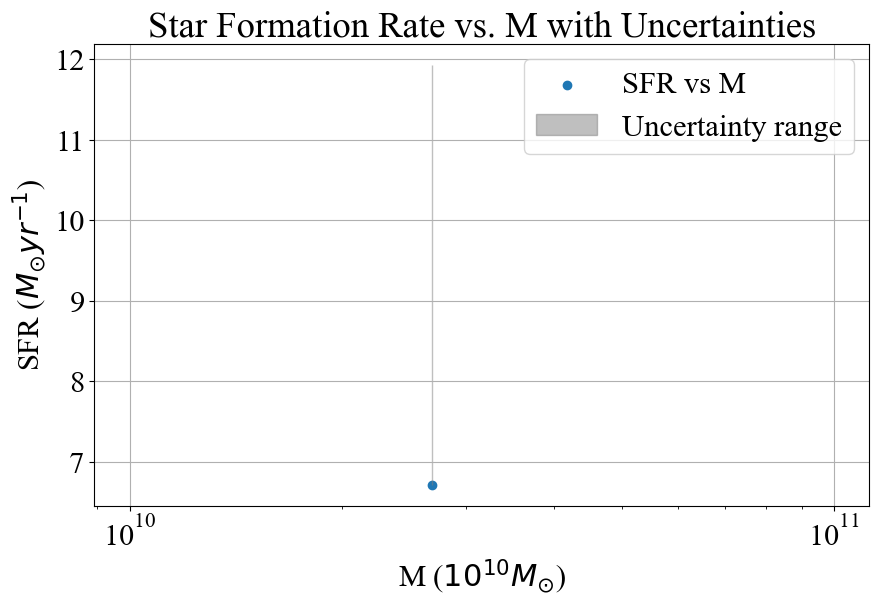

In [60]:
import numpy as np
import matplotlib.pyplot as plt


# M range and uncertainties
# M_values = np.linspace(1e10, 1e11, 100)
M_values=[2.69e10]
mu = 0.91e10  # Assuming 10% uncertainty for +mu
mn = 0e10  # Assuming 10% uncertainty for -mn

# Calculate SFR and uncertainties
SFR_values = sfr(convert_mass_hinv_to_msun(M_values[0], h))
SFR_upper = sfr(convert_mass_hinv_to_msun(M_values[0]+mu, h))
SFR_lower = sfr(convert_mass_hinv_to_msun(M_values[0]-mn, h))

# Plot
plt.figure(figsize=(10, 6))

plt.xscale('log')
plt.xscale('log')

plt.scatter(M_values, SFR_values, label='SFR vs M')
plt.fill_between(M_values, SFR_lower, SFR_upper, color='gray', alpha=0.5, label='Uncertainty range')

plt.xlabel('M ($10^{10} M_{\odot}$)')
plt.ylabel('SFR ($M_{\odot} yr^{-1}$)')
plt.title('Star Formation Rate vs. M with Uncertainties')
plt.legend()
plt.grid(True)
plt.show()


In [55]:
def convert_mass_hinv_to_msun(mass_hinv, h):
    """
    Convert mass from M_sun h^-1 to M_sun.

    Parameters:
    - mass_hinv: float or np.array, mass in units of M_sun h^-1
    - h: float, dimensionless Hubble parameter

    Returns:
    - mass in units of M_sun
    """
    return mass_hinv * h

# Example usage:
h = 0.7  # Example value for the dimensionless Hubble parameter
mass_hinv = 1e10  # Example mass in M_sun h^-1
mass_msun = convert_mass_hinv_to_msun(mass_hinv, h)
print(f"Mass in M_sun: {mass_msun} M_sun")

Mass in M_sun: 7000000000.0 M_sun


In [84]:
M=np.array([2.92,3.72,5.54])
MC=np.array([[3.3,3.1,2.6,1.6,2.5],[3.8,2.9,3.5,3.1,3.7],[6.0,5.68,4.9,4.87,4.6]])
MU =np.array([[1.2,1.2,2.1,1.9,1.4],[1.9,3.0,0.95,1.4,1.8],[1.1,0.8,1.2,0.62,1.1]])  # Assuming 10% uncertainty for +mu
MN =np.array([[1.3,1.2,2.1,0.0,0.0],[1.5,1.1,0.93,0.0,2.1],[1.3,0.77,1.0,0.63,0.0]]) # Assuming 10% uncertainty for -mn

for i in range(len(M)):
    m=M[i]*1e10
    print("\n\n\nMass: ",M[i])
    print("True SFR: ",sfr(convert_mass_hinv_to_msun(m, h)))
    for j in range(len(MC[i])):
        mc=MC[i,j]*1e10
        mu=MU[i,j]*1e10
        mn=MN[i,j]*1e10
        print("Constrained mass: ",MC[i,j])
        # Calculate SFR and uncertainties
        sc=sfr(convert_mass_hinv_to_msun(mc, h))
        su=sfr(convert_mass_hinv_to_msun(mc+mu, h))
        sl=sfr(convert_mass_hinv_to_msun(mc-mn, h))
        # print("Mean constrained SFR: ",sfr(convert_mass_hinv_to_msun(mc, h)))
        # print("Upper deviation: ",sfr(convert_mass_hinv_to_msun(mc+mu, h)))
        # print("Lower deviation: ",sfr(convert_mass_hinv_to_msun(mc-mn, h)))
        print("{"+str(round(sc,2))+"}^{+"+str(round(su-sc,2))+"}_{"+str(round(sl-sc,2))+"}")




Mass:  2.92
True SFR:  7.907449355007401
Constrained mass:  3.3
{10.07}^{+8.18}_{-6.4}
Constrained mass:  3.1
{8.9}^{+7.85}_{-5.6}
Constrained mass:  2.6
{6.27}^{+13.52}_{-6.08}
Constrained mass:  1.6
{2.31}^{+8.99}_{0.0}
Constrained mass:  2.5
{5.79}^{+8.13}_{0.0}



Mass:  3.72
True SFR:  12.709180258539655
Constrained mass:  3.8
{13.24}^{+14.9}_{-8.35}
Constrained mass:  2.9
{7.8}^{+22.13}_{-4.85}
Constrained mass:  3.5
{11.29}^{+6.58}_{-5.17}
Constrained mass:  3.1
{8.9}^{+9.35}_{0.0}
Constrained mass:  3.7
{12.58}^{+13.81}_{-10.27}



Mass:  5.54
True SFR:  26.73808366645019
Constrained mass:  6.0
{30.83}^{+10.49}_{-11.04}
Constrained mass:  5.68
{27.96}^{+7.33}_{-6.51}
Constrained mass:  4.9
{21.38}^{+10.37}_{-7.46}
Constrained mass:  4.87
{21.14}^{+5.17}_{-4.82}
Constrained mass:  4.6
{19.01}^{+9.13}_{0.0}


In [64]:
convert_mass_hinv_to_msun(2.69e10,h)

18830000000.0

In [74]:
mu=0.86
mu=0.86*1e10
print(mu)

8600000000.0
